[Saved] imgs/conjugate_gradient/banded_convergence_b2_n2000.pdf
n=  500, κ≈7.25e+03: iters CG=1404, PR=68, WJ=91
n= 1000, κ≈7.17e+03: iters CG=1733, PR=69, WJ=92
n= 2000, κ≈6.89e+03: iters CG=1933, PR=68, WJ=91
n= 4000, κ≈6.96e+03: iters CG=2068, PR=69, WJ=93
[Saved] imgs/conjugate_gradient/banded_iterations_vs_n_b2.pdf
n=  200: κ(A0)≈8.35e+03, κ(A)≈8.35e+03 (fallback)
n=  400: κ(A0)≈7.74e+03, κ(A)≈7.74e+03 (fallback)
n=  800: κ(A0)≈7.11e+03, κ(A)≈7.11e+03 (fallback)
n= 1600: κ(A0)≈6.99e+03, κ(A)≈6.99e+03 (fallback)
n= 2400: κ(A0)≈6.81e+03, κ(A)≈6.81e+03 (fallback)
[Saved] imgs/conjugate_gradient/banded_kappa_vs_n_b2.pdf

--- Sanity check (n=1000, b=2) ---
Half-bandwidth: 2 | measured κ≈ 7.17e+03
CG                 iters=1664, time=0.462s, final_res=8.93e-09
PR(Jacobi)         iters=70, time=0.019s, final_res=7.86e-09
Weighted Jacobi    iters=92, time=0.020s, final_res=8.66e-09
Direct (spsolve)   iters=-, time=0.009s, final_res=2.18e-16
[Saved] imgs/conjugate_gradient/banded_convergenc

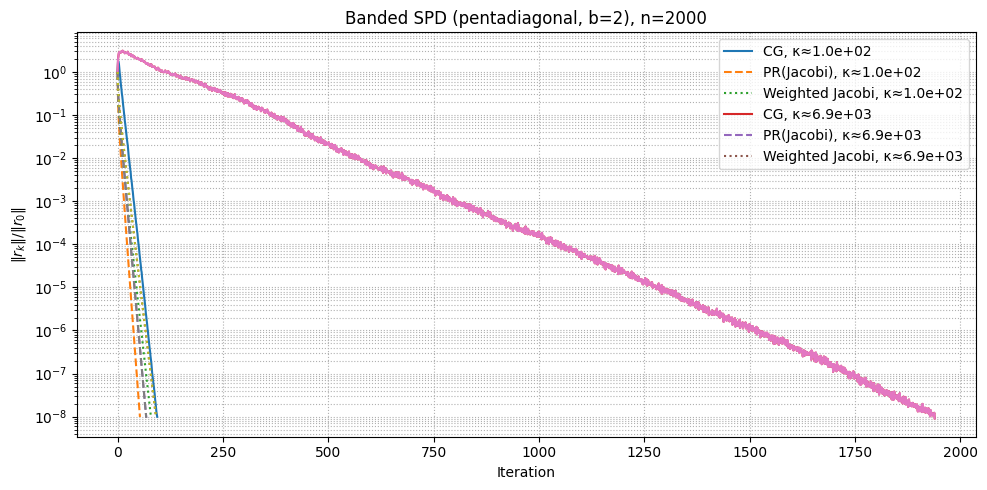

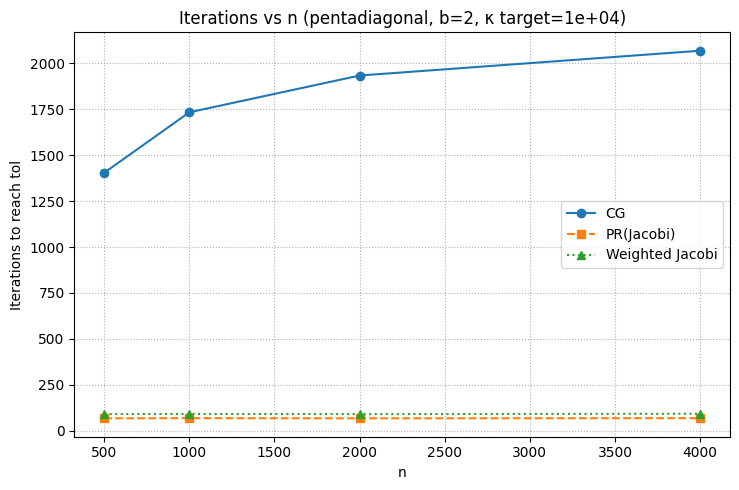

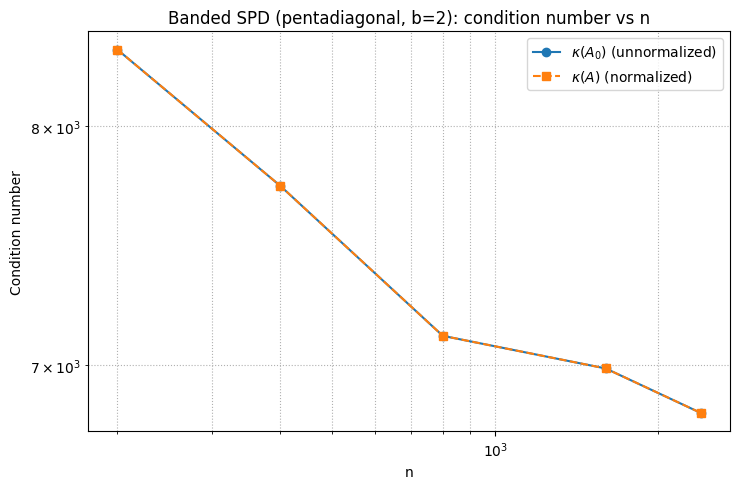

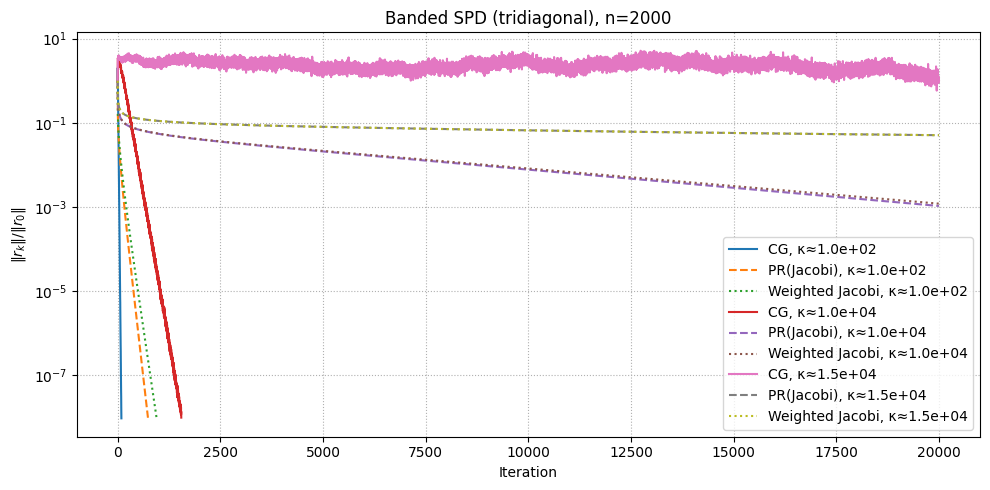

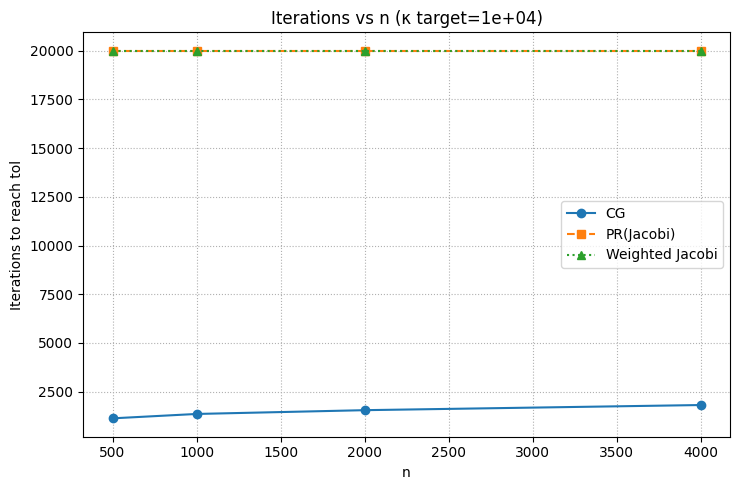

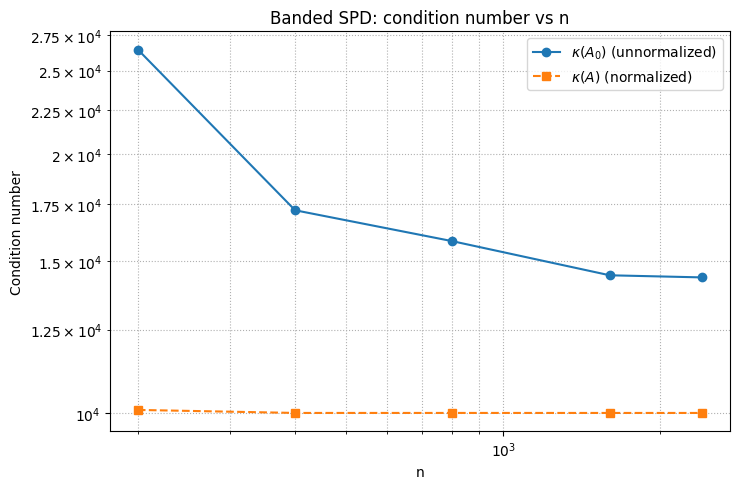

In [1]:

# Banded SPD (pentadiagonal) experiments with diagonal congruence + kappa control.
# Solvers: CG, PR(Jacobi), Weighted Jacobi, Direct sparse LU.
# Figures saved to imgs/conjugate_gradient/*.pdf

import os, numpy as np
import scipy.sparse as sps
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
from dataclasses import dataclass
from time import perf_counter

# ---------- setup ----------
np.set_printoptions(precision=3, suppress=True)
os.makedirs("imgs/conjugate_gradient", exist_ok=True)

DEFAULT_TOL   = 1e-8
DEFAULT_MAXIT = 20000
DEFAULT_SEED  = 123

@dataclass
class GenParams:
    n: int = 2000
    beta: float = 2.0       # diagonal range ~ 10^(2*beta)
    sigma: float = 0.0      # optional diagonal shift for A0
    theta: float = 0.1      # mu = theta * lambda_min(A0)
    kappa_target: float = 1e4
    # Fixed to b=2 (pentadiagonal)
    stencil: str = "penta"  # do not change if you want half-bandwidth = 2

# ---------- helpers ----------
def norm2(v): return float(np.linalg.norm(v))
def safe_symmetrize(A): return ((A + A.T) * 0.5).tocsr()

def tridiag(n, a, b, c):
    diags = [a*np.ones(n-1), b*np.ones(n), c*np.ones(n-1)]
    return sps.diags([diags[0], diags[1], diags[2]], offsets=[-1,0,1], format='csr')

def penta_only(n, a1_off=-0.5, a2_off=-0.25, main_add=2.0):
    # Build a pentadiagonal with ±1 = a1_off, ±2 = a2_off, and main = main_add
    diags = [
        a2_off*np.ones(n-2), a1_off*np.ones(n-1), main_add*np.ones(n),
        a1_off*np.ones(n-1), a2_off*np.ones(n-2)
    ]
    return sps.diags(diags, offsets=[-2,-1,0,1,2], format='csr')

def make_stencil(n, stencil="penta"):
    if stencil != "penta":
        raise ValueError("This script is fixed to half-bandwidth b=2 (stencil='penta').")
    # Strictly diagonally dominant SPD pentadiagonal (b=2)
    S = penta_only(n, a1_off=-0.5, a2_off=-0.25, main_add=2.0)
    b = 2
    return S.tocsr(), b

def diagonal_congruence(S, beta=2.0, sigma=0.0):
    n = S.shape[0]
    d = 10.0 ** (beta * np.linspace(0, 1, n))
    D = sps.diags(d, format='csr')
    A0 = (D @ S @ D).tocsr()
    if sigma != 0.0:
        A0 = A0 + sigma * sps.eye(n, format='csr')
    return safe_symmetrize(A0)

# ---------- short Lanczos for extremal eigenvalues (no ARPACK) ----------
def lanczos_extremal(A, m=80, seed=DEFAULT_SEED):
    A = safe_symmetrize(A)
    n = A.shape[0]
    rng = np.random.default_rng(seed)
    q_prev = np.zeros(n)
    q = rng.standard_normal(n); q /= norm2(q)
    alphas, betas = [], []
    beta = 0.0
    for j in range(m):
        z = A @ q
        alpha = float(q @ z)
        w = z - alpha*q - beta*q_prev
        # light reorthogonalization against last two
        if j > 0: w -= (q_prev @ w)*q_prev
        w -= (q @ w)*q
        beta = norm2(w)
        alphas.append(alpha)
        if j < m-1: betas.append(beta)
        if beta < 1e-14: break
        q_prev, q = q, w/beta
    k = len(alphas)
    T = np.diag(alphas)
    if k > 1:
        off = np.array(betas[:k-1])
        T += np.diag(off,1) + np.diag(off,-1)
    evals = np.linalg.eigvalsh(T)
    return float(evals[0]), float(evals[-1])

def measure_extreme_eigs(A, m=80):
    try:
        lam_min, lam_max = lanczos_extremal(A, m=m)
        if lam_min <= 0:
            shift = -lam_min + 1e-12
            A = A + shift * sps.eye(A.shape[0], format='csr')
            lam_min, lam_max = lanczos_extremal(A, m=m)
        return lam_min, lam_max
    except Exception:
        Ad = A.diagonal()
        abs_off = np.abs(A) - sps.diags(np.abs(Ad), format='csr')
        row_sums = np.array(abs_off.sum(axis=1)).ravel()
        g_min = float((Ad - row_sums).min())
        g_max = float((Ad + row_sums).max())
        return max(g_min, 1e-12), g_max

# ---------- spectral normalization to target kappa ----------
def spectral_normalize_to_kappa(A0, kappa_target, theta=0.1):
    lam_min0, lam_max0 = measure_extreme_eigs(A0, m=80)
    if lam_min0 <= 0:
        shift = (1 - lam_min0) + 1e-8
        A0 = A0 + shift * sps.eye(A0.shape[0], format='csr')
        lam_min0 += shift; lam_max0 += shift
    mu = theta * lam_min0
    denom = (kappa_target * lam_min0 - lam_max0)
    a = ((1.0 - kappa_target) * mu) / denom
    tries = 0
    while (a <= 0) or not np.isfinite(a):
        theta *= 2.0
        mu = theta * lam_min0
        denom = (kappa_target * lam_min0 - lam_max0)
        a = ((1.0 - kappa_target) * mu) / denom
        tries += 1
        if tries > 8:
            A = safe_symmetrize(A0.copy())
            lam_min, lam_max = measure_extreme_eigs(A, m=80)
            return A, dict(lam_min0=lam_min0, lam_max0=lam_max0, mu=0.0, a=1.0,
                           lam_min=lam_min, lam_max=lam_max, kappa_measured=lam_max/lam_min, fallback=True)
    A = (a * A0 + mu * sps.eye(A0.shape[0], format='csr')).tocsr()
    A = safe_symmetrize(A)
    lam_min, lam_max = measure_extreme_eigs(A, m=80)
    return A, dict(lam_min0=lam_min0, lam_max0=lam_max0, mu=mu, a=a,
                   lam_min=lam_min, lam_max=lam_max, kappa_measured=float(lam_max/lam_min),
                   fallback=False, theta_used=theta)

def generate_banded_spd(params: GenParams):
    S, half_bw = make_stencil(params.n, params.stencil)
    A0 = diagonal_congruence(S, beta=params.beta, sigma=params.sigma)
    if params.kappa_target is None:
        lam_min, lam_max = measure_extreme_eigs(A0, m=80)
        return A0, half_bw, dict(lam_min=lam_min, lam_max=lam_max, kappa_measured=lam_max/lam_min)
    A, info = spectral_normalize_to_kappa(A0, params.kappa_target, theta=params.theta)
    return A, half_bw, info

# ---------- solvers ----------
def cg_solver(A, b, x0=None, tol=DEFAULT_TOL, maxit=DEFAULT_MAXIT):
    n = A.shape[0]
    x = np.zeros(n) if x0 is None else x0.copy()
    r = b - A @ x; p = r.copy()
    rs_old = r @ r; res0 = np.sqrt(rs_old)
    res_hist = [res0]; t0 = perf_counter()
    if res0 == 0.0: return x, dict(iters=0, res_hist=np.array(res_hist), time=0.0)
    for k in range(1, maxit+1):
        Ap = A @ p
        denom = float(p @ Ap)
        if abs(denom) < 1e-30: break
        alpha = rs_old / denom
        x += alpha * p
        r -= alpha * Ap
        rs_new = r @ r; res = np.sqrt(rs_new)
        res_hist.append(res)
        if res <= tol * res0: break
        beta = rs_new / max(1e-30, rs_old)
        p = r + beta * p
        rs_old = rs_new
    t1 = perf_counter()
    return x, dict(iters=k, res_hist=np.array(res_hist), time=t1-t0)

def pr_jacobi_solver(A, b, x0=None, tol=DEFAULT_TOL, maxit=DEFAULT_MAXIT):
    n = A.shape[0]
    x = np.zeros(n) if x0 is None else x0.copy()
    D = A.diagonal(); M_inv = 1.0 / D
    r = b - A @ x; res0 = norm2(r); res_hist = [res0]
    if res0 == 0.0: return x, dict(iters=0, res_hist=np.array(res_hist), time=0.0)
    s = M_inv * r; As = A @ s
    denom = float(As @ As)
    omega = float(r @ As) / denom if denom != 0 else 1.0
    t0 = perf_counter()
    for k in range(1, maxit+1):
        x += omega * s
        r = b - A @ x
        res = norm2(r); res_hist.append(res)
        if res <= tol * res0: break
        s = M_inv * r
    t1 = perf_counter()
    return x, dict(iters=k, res_hist=np.array(res_hist), time=t1-t0, omega=omega)

def weighted_jacobi_solver(A, b, x0=None, tol=DEFAULT_TOL, maxit=DEFAULT_MAXIT, omega=2/3):
    n = A.shape[0]
    x = np.zeros(n) if x0 is None else x0.copy()
    D = A.diagonal(); Minv = 1.0 / D
    r = b - A @ x; res0 = norm2(r); res_hist = [res0]
    if res0 == 0.0: return x, dict(iters=0, res_hist=np.array(res_hist), time=0.0)
    t0 = perf_counter()
    for k in range(1, maxit+1):
        x = x + omega * (Minv * r)
        r = b - A @ x
        res = norm2(r); res_hist.append(res)
        if res <= tol * res0: break
    t1 = perf_counter()
    return x, dict(iters=k, res_hist=np.array(res_hist), time=t1-t0)

def direct_banded_solver(A, b):
    t0 = perf_counter()
    x = spla.spsolve(A.tocsc(), b, permc_spec="NATURAL")
    t1 = perf_counter()
    return x, dict(time=t1-t0)

def run_all_methods(A, bvec, tol=DEFAULT_TOL, maxit=DEFAULT_MAXIT):
    out = {}
    x_cg, info_cg = cg_solver(A, bvec, tol=tol, maxit=maxit); out['CG'] = (x_cg, info_cg)
    x_pr, info_pr = pr_jacobi_solver(A, bvec, tol=tol, maxit=maxit); out['PR(Jacobi)'] = (x_pr, info_pr)
    x_wj, info_wj = weighted_jacobi_solver(A, bvec, tol=tol, maxit=maxit); out['Weighted Jacobi'] = (x_wj, info_wj)
    x_dir, info_dir = direct_banded_solver(A, bvec); out['Direct (spsolve)'] = (x_dir, info_dir)
    for name in out:
        x, inf = out[name]
        inf['final_res'] = norm2(bvec - A @ x)
    return out

# ---------- figures ----------
def plot_convergence_n_b2(n=2000, beta=2.0, sigma=0.0, ks=(1e2,1e4,1e6),
                          tol=DEFAULT_TOL, maxit=DEFAULT_MAXIT, seed=DEFAULT_SEED,
                          savepath="imgs/conjugate_gradient/banded_convergence_b2_n2000.pdf"):
    np.random.seed(seed)
    bvec = np.random.randn(n); bvec /= norm2(bvec)
    plt.figure(figsize=(10,5))
    for kappa_target in ks:
        params = GenParams(n=n, beta=beta, sigma=sigma, theta=0.1,
                           kappa_target=kappa_target, stencil="penta")
        A, half_bw, info = generate_banded_spd(params)
        out = run_all_methods(A, bvec, tol=tol, maxit=maxit)
        for name, ls in [('CG','-'), ('PR(Jacobi)','--'), ('Weighted Jacobi',':')]:
            res_hist = out[name][1]['res_hist']
            plt.semilogy(res_hist / max(1e-30, res_hist[0]), ls,
                         label=f"{name}, κ≈{info['kappa_measured']:.1e}")
    plt.xlabel("Iteration"); plt.ylabel(r"$\|r_k\| / \|r_0\|$")
    plt.title(f"Banded SPD (pentadiagonal, b=2), n={n}")
    plt.grid(True, which='both', ls=':')
    # de-duplicate legend
    handles, labels = plt.gca().get_legend_handles_labels()
    seen, newh, newl = set(), [], []
    for h,l in zip(handles, labels):
        if l not in seen: newh.append(h); newl.append(l); seen.add(l)
    plt.legend(newh, newl)
    plt.tight_layout(); plt.savefig(savepath)
    print(f"[Saved] {savepath}")

def iterations_vs_n_b2(beta=2.0, sigma=0.0, kappa_target=1e4,
                       ns=(500, 1000, 2000, 4000),
                       tol=DEFAULT_TOL, maxit=DEFAULT_MAXIT, seed=DEFAULT_SEED,
                       savepath="imgs/conjugate_gradient/banded_iterations_vs_n_b2.pdf"):
    np.random.seed(seed)
    iters = {'CG': [], 'PR(Jacobi)': [], 'Weighted Jacobi': []}
    for n in ns:
        params = GenParams(n=n, beta=beta, sigma=sigma, theta=0.1,
                           kappa_target=kappa_target, stencil="penta")
        A, half_bw, info = generate_banded_spd(params)
        bvec = np.random.randn(n); bvec /= norm2(bvec)
        out = run_all_methods(A, bvec, tol=tol, maxit=maxit)
        for k in iters.keys(): iters[k].append(out[k][1]['iters'])
        print(f"n={n:5d}, κ≈{info['kappa_measured']:.2e}: "
              f"iters CG={iters['CG'][-1]}, PR={iters['PR(Jacobi)'][-1]}, WJ={iters['Weighted Jacobi'][-1]}")
    plt.figure(figsize=(7.5,5))
    for k, style in zip(iters.keys(), ['-o','--s',':^']):
        plt.plot(ns, iters[k], style, label=k)
    plt.xlabel("n"); plt.ylabel("Iterations to reach tol")
    plt.title(f"Iterations vs n (pentadiagonal, b=2, κ target={kappa_target:.0e})")
    plt.grid(True, ls=':'); plt.legend()
    plt.tight_layout(); plt.savefig(savepath)
    print(f"[Saved] {savepath}")

def kappa_vs_n_b2(beta=2.0, sigma=0.0, kappa_target=1e4,
                  ns=(200, 400, 800, 1600, 2400),
                  savepath="imgs/conjugate_gradient/banded_kappa_vs_n_b2.pdf"):
    kappas_A0, kappas_Anorm = [], []
    for n in ns:
        S, _ = make_stencil(n, stencil="penta")
        A0 = diagonal_congruence(S, beta=beta, sigma=sigma)
        lam_min0, lam_max0 = measure_extreme_eigs(A0, m=80)
        kappas_A0.append(lam_max0 / lam_min0)
        A, info = spectral_normalize_to_kappa(A0, kappa_target, theta=0.1)
        kappas_Anorm.append(info['kappa_measured'])
        print(f"n={n:5d}: κ(A0)≈{kappas_A0[-1]:.2e}, κ(A)≈{kappas_Anorm[-1]:.2e} "
              f"{'(fallback)' if info.get('fallback', False) else ''}")
    plt.figure(figsize=(7.5,5))
    plt.loglog(ns, kappas_A0, '-o', label=r'$\kappa(A_0)$ (unnormalized)')
    plt.loglog(ns, kappas_Anorm, '--s', label=r'$\kappa(A)$ (normalized)')
    plt.xlabel("n"); plt.ylabel("Condition number")
    plt.title("Banded SPD (pentadiagonal, b=2): condition number vs n")
    plt.grid(True, which='both', ls=':'); plt.legend()
    plt.tight_layout(); plt.savefig(savepath)
    print(f"[Saved] {savepath}")

# ---------- run everything ----------
if __name__ == "__main__":
    # Figure 1: convergence for n=2000, b=2
    plot_convergence_n_b2(n=2000, beta=2.0, sigma=0.0,
                          ks=(1e2, 1e4, 1e6),
                          tol=DEFAULT_TOL, maxit=DEFAULT_MAXIT, seed=DEFAULT_SEED,
                          savepath="imgs/conjugate_gradient/banded_convergence_b2_n2000.pdf")

    # Figure 2: iterations vs n (trimmed set for speed)
    iterations_vs_n_b2(beta=2.0, sigma=0.0, kappa_target=1e4,
                       ns=(500, 1000, 2000, 4000),
                       tol=DEFAULT_TOL, maxit=DEFAULT_MAXIT, seed=DEFAULT_SEED,
                       savepath="imgs/conjugate_gradient/banded_iterations_vs_n_b2.pdf")

    # Figure 3: kappa vs n
    kappa_vs_n_b2(beta=2.0, sigma=0.0, kappa_target=1e4,
                  ns=(200, 400, 800, 1600, 2400),
                  savepath="imgs/conjugate_gradient/banded_kappa_vs_n_b2.pdf")

    # Sanity check print
    params = GenParams(n=1000, beta=2.0, sigma=0.0, theta=0.1, kappa_target=1e4, stencil="penta")
    A, bw, info = generate_banded_spd(params)
    bvec = np.random.randn(params.n); bvec /= norm2(bvec)
    out = run_all_methods(A, bvec)
    print("\n--- Sanity check (n=1000, b=2) ---")
    print("Half-bandwidth:", bw, "| measured κ≈", f"{info['kappa_measured']:.2e}")
    for name in out:
        x, inf = out[name]
        print(f"{name:18s} iters={inf.get('iters','-')}, time={inf['time']:.3f}s, final_res={inf['final_res']:.2e}")

# Builds banded SPD matrices, normalizes to target κ using a custom Lanczos
# (no scipy.sparse.linalg.eigsh), runs CG / PR(Jacobi) / Weighted Jacobi / Direct,
# and saves figures:
#   imgs/conjugate_gradient/banded_convergence_n2000.pdf
#   imgs/conjugate_gradient/banded_iterations_vs_n.pdf
#   imgs/conjugate_gradient/banded_kappa_vs_n.pdf

import os, numpy as np
import scipy.sparse as sps
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
from dataclasses import dataclass
from time import perf_counter

# ---------- setup ----------
np.set_printoptions(precision=3, suppress=True)
os.makedirs("imgs/conjugate_gradient", exist_ok=True)

DEFAULT_TOL   = 1e-8
DEFAULT_MAXIT = 20000
DEFAULT_SEED  = 123

@dataclass
class GenParams:
    n: int = 2000           # safe default for Colab
    beta: float = 2.0       # diagonal range ~ 10^(2*beta)
    sigma: float = 0.0      # optional diagonal shift for A0
    theta: float = 0.1      # mu = theta * lambda_min(A0)
    kappa_target: float = 1e4
    stencil: str = "tri"    # "tri" or "penta"

# ---------- helpers ----------
def norm2(v): return float(np.linalg.norm(v))

def safe_symmetrize(A):
    """Force exact symmetry (CSR ops can introduce tiny asymmetries)."""
    return ((A + A.T) * 0.5).tocsr()

def tridiag(n, a, b, c):
    diags = [a*np.ones(n-1), b*np.ones(n), c*np.ones(n-1)]
    return sps.diags([diags[0], diags[1], diags[2]], offsets=[-1,0,1], format='csr')

def pentadiag(n, a2_off, main_add=0.0):
    diags = [
        a2_off*np.ones(n-2), np.zeros(n-1), main_add*np.ones(n),
        np.zeros(n-1), a2_off*np.ones(n-2)
    ]
    return sps.diags(diags, offsets=[-2,-1,0,1,2], format='csr')

def make_stencil(n, stencil="tri"):
    if stencil == "tri":
        S = tridiag(n, -1.0, 2.0, -1.0); b = 1
    elif stencil == "penta":
        S = tridiag(n, -0.5, 2.0, -0.5) + pentadiag(n, a2_off=-0.25, main_add=0.0); b = 2
    else:
        raise ValueError("stencil must be 'tri' or 'penta'")
    return S.tocsr(), b

def diagonal_congruence(S, beta=2.0, sigma=0.0):
    n = S.shape[0]
    d = 10.0 ** (beta * np.linspace(0, 1, n))
    D = sps.diags(d, format='csr')
    A0 = (D @ S @ D).tocsr()
    if sigma != 0.0:
        A0 = A0 + sigma * sps.eye(n, format='csr')
    return safe_symmetrize(A0)

# ---------- small, robust Lanczos (no ARPACK) ----------
def lanczos_extremal(A, m=80, seed=DEFAULT_SEED):
    """
    Return (~lam_min, ~lam_max) for symmetric A via short Lanczos.
    m: Krylov subspace size (60-100 is usually fine).
    """
    A = safe_symmetrize(A)
    n = A.shape[0]
    rng = np.random.default_rng(seed)
    q_prev = np.zeros(n)
    q = rng.standard_normal(n); q /= norm2(q)
    alphas = []
    betas = []

    beta = 0.0
    for j in range(m):
        z = A @ q
        alpha = float(q @ z)
        w = z - alpha * q - beta * q_prev
        # full reorth against last two to mitigate loss of orthogonality (cheap)
        if j > 0:
            w -= (q_prev @ w) * q_prev
        w -= (q @ w) * q
        beta = norm2(w)
        alphas.append(alpha)
        if j < m - 1:
            betas.append(beta)
        if beta < 1e-14:
            # converged early; shrink T to size j+1
            break
        q_prev, q = q, (w / beta)

    k = len(alphas)
    T = np.diag(alphas)
    if k > 1:
        off = np.array(betas[:k-1])
        T += np.diag(off, 1) + np.diag(off, -1)
    # Small dense eigenproblem
    evals = np.linalg.eigvalsh(T)
    return float(evals[0]), float(evals[-1])

def measure_extreme_eigs(A, m=80):
    """Wrapper using custom Lanczos with Gershgorin fallback."""
    try:
        lam_min, lam_max = lanczos_extremal(A, m=m)
        if lam_min <= 0:
            # Ensure SPD by tiny diagonal shift if numerical noise
            shift = -lam_min + 1e-12
            A = A + shift * sps.eye(A.shape[0], format='csr')
            lam_min2, lam_max2 = lanczos_extremal(A, m=m)
            return lam_min2, lam_max2
        return lam_min, lam_max
    except Exception:
        # Gershgorin crude fallback
        Ad = A.diagonal()
        abs_off = np.abs(A) - sps.diags(np.abs(Ad), format='csr')
        row_sums = np.array(abs_off.sum(axis=1)).ravel()
        g_min = float((Ad - row_sums).min())
        g_max = float((Ad + row_sums).max())
        return max(g_min, 1e-12), g_max

# ---------- spectral normalization to target κ ----------
def spectral_normalize_to_kappa(A0, kappa_target, theta=0.1):
    lam_min0, lam_max0 = measure_extreme_eigs(A0, m=80)
    if lam_min0 <= 0:
        shift = (1 - lam_min0) + 1e-8
        A0 = A0 + shift * sps.eye(A0.shape[0], format='csr')
        lam_min0 += shift; lam_max0 += shift

    mu = theta * lam_min0
    # closed form: kappa = (a*Lmax + mu) / (a*Lmin + mu)
    denom = (kappa_target * lam_min0 - lam_max0)
    a = ((1.0 - kappa_target) * mu) / denom

    tries = 0
    while (a <= 0) or not np.isfinite(a):
        theta *= 2.0
        mu = theta * lam_min0
        denom = (kappa_target * lam_min0 - lam_max0)
        a = ((1.0 - kappa_target) * mu) / denom
        tries += 1
        if tries > 8:
            # Fallback: accept A0 (scaled to positive) without aiming exact kappa
            A = safe_symmetrize(A0.copy())
            lam_min, lam_max = measure_extreme_eigs(A, m=80)
            return A, dict(lam_min0=lam_min0, lam_max0=lam_max0, mu=0.0, a=1.0,
                           lam_min=lam_min, lam_max=lam_max, kappa_measured=lam_max/lam_min, fallback=True)

    A = (a * A0 + mu * sps.eye(A0.shape[0], format='csr')).tocsr()
    A = safe_symmetrize(A)
    lam_min, lam_max = measure_extreme_eigs(A, m=80)
    return A, dict(lam_min0=lam_min0, lam_max0=lam_max0, mu=mu, a=a,
                   lam_min=lam_min, lam_max=lam_max, kappa_measured=float(lam_max/lam_min),
                   fallback=False, theta_used=theta)

def generate_banded_spd(params: GenParams):
    S, half_bw = make_stencil(params.n, params.stencil)
    A0 = diagonal_congruence(S, beta=params.beta, sigma=params.sigma)
    if params.kappa_target is None:
        lam_min, lam_max = measure_extreme_eigs(A0, m=80)
        return A0, half_bw, dict(lam_min=lam_min, lam_max=lam_max, kappa_measured=lam_max/lam_min)
    A, info = spectral_normalize_to_kappa(A0, params.kappa_target, theta=params.theta)
    return A, half_bw, info

# ---------- solvers ----------
def cg_solver(A, b, x0=None, tol=DEFAULT_TOL, maxit=DEFAULT_MAXIT):
    n = A.shape[0]
    x = np.zeros(n) if x0 is None else x0.copy()
    r = b - A @ x; p = r.copy()
    rs_old = r @ r; res0 = np.sqrt(rs_old)
    res_hist = [res0]; t0 = perf_counter()
    if res0 == 0.0: return x, dict(iters=0, res_hist=np.array(res_hist), time=0.0)

    for k in range(1, maxit+1):
        Ap = A @ p
        denom = float(p @ Ap)
        if abs(denom) < 1e-30: break
        alpha = rs_old / denom
        x += alpha * p
        r -= alpha * Ap
        rs_new = r @ r; res = np.sqrt(rs_new)
        res_hist.append(res)
        if res <= tol * res0: break
        beta = rs_new / max(1e-30, rs_old)
        p = r + beta * p
        rs_old = rs_new
    t1 = perf_counter()
    return x, dict(iters=k, res_hist=np.array(res_hist), time=t1-t0)

def pr_jacobi_solver(A, b, x0=None, tol=DEFAULT_TOL, maxit=DEFAULT_MAXIT):
    n = A.shape[0]
    x = np.zeros(n) if x0 is None else x0.copy()
    D = A.diagonal(); M_inv = 1.0 / D
    r = b - A @ x; res0 = norm2(r); res_hist = [res0]
    if res0 == 0.0: return x, dict(iters=0, res_hist=np.array(res_hist), time=0.0)
    # one-step line search for omega at k=0
    s = M_inv * r; As = A @ s
    denom = float(As @ As)
    omega = float(r @ As) / denom if denom != 0 else 1.0
    t0 = perf_counter()
    for k in range(1, maxit+1):
        x += omega * s
        r = b - A @ x
        res = norm2(r); res_hist.append(res)
        if res <= tol * res0: break
        s = M_inv * r
    t1 = perf_counter()
    return x, dict(iters=k, res_hist=np.array(res_hist), time=t1-t0, omega=omega)

def weighted_jacobi_solver(A, b, x0=None, tol=DEFAULT_TOL, maxit=DEFAULT_MAXIT, omega=2/3):
    n = A.shape[0]
    x = np.zeros(n) if x0 is None else x0.copy()
    D = A.diagonal(); Minv = 1.0 / D
    r = b - A @ x; res0 = norm2(r); res_hist = [res0]
    if res0 == 0.0: return x, dict(iters=0, res_hist=np.array(res_hist), time=0.0)
    t0 = perf_counter()
    for k in range(1, maxit+1):
        x = x + omega * (Minv * r)
        r = b - A @ x
        res = norm2(r); res_hist.append(res)
        if res <= tol * res0: break
    t1 = perf_counter()
    return x, dict(iters=k, res_hist=np.array(res_hist), time=t1-t0)

def direct_banded_solver(A, b):
    t0 = perf_counter()
    x = spla.spsolve(A.tocsc(), b, permc_spec="NATURAL")
    t1 = perf_counter()
    return x, dict(time=t1-t0)

def run_all_methods(A, b, tol=DEFAULT_TOL, maxit=DEFAULT_MAXIT):
    out = {}
    x_cg, info_cg = cg_solver(A, b, tol=tol, maxit=maxit); out['CG'] = (x_cg, info_cg)
    x_pr, info_pr = pr_jacobi_solver(A, b, tol=tol, maxit=maxit); out['PR(Jacobi)'] = (x_pr, info_pr)
    x_wj, info_wj = weighted_jacobi_solver(A, b, tol=tol, maxit=maxit); out['Weighted Jacobi'] = (x_wj, info_wj)
    x_dir, info_dir = direct_banded_solver(A, b); out['Direct (spsolve)'] = (x_dir, info_dir)
    for name in out:
        x, inf = out[name]
        inf['final_res'] = norm2(b - A @ x)
    return out

# ---------- figures ----------
def plot_convergence_n(stencil="tri", n=2000, beta=2.0, sigma=0.0, ks=(1e2,1e4,1e6),
                       tol=DEFAULT_TOL, maxit=DEFAULT_MAXIT, seed=DEFAULT_SEED,
                       savepath="imgs/conjugate_gradient/banded_convergence_n2000.pdf"):
    np.random.seed(seed)
    bvec = np.random.randn(n); bvec = bvec / norm2(bvec)
    plt.figure(figsize=(10,5))
    for kappa_target in ks:
        params = GenParams(n=n, beta=beta, sigma=sigma, theta=0.1,
                           kappa_target=kappa_target, stencil=stencil)
        A, half_bw, info = generate_banded_spd(params)
        out = run_all_methods(A, bvec, tol=tol, maxit=maxit)
        for name, ls in [('CG','-'), ('PR(Jacobi)','--'), ('Weighted Jacobi',':')]:
            res_hist = out[name][1]['res_hist']
            plt.semilogy(res_hist / max(1e-30, res_hist[0]), ls,
                         label=f"{name}, κ≈{info['kappa_measured']:.1e}")
    plt.xlabel("Iteration"); plt.ylabel(r"$\|r_k\| / \|r_0\|$")
    plt.title(f"Banded SPD ({'tridiagonal' if stencil=='tri' else 'pentadiagonal'}), n={n}")
    plt.grid(True, which='both', ls=':')
    # de-duplicate legend
    handles, labels = plt.gca().get_legend_handles_labels()
    seen, newh, newl = set(), [], []
    for h,l in zip(handles, labels):
        if l not in seen: newh.append(h); newl.append(l); seen.add(l)
    plt.legend(newh, newl)
    plt.tight_layout(); plt.savefig(savepath)
    print(f"[Saved] {savepath}")

def iterations_vs_n(stencil="tri", beta=2.0, sigma=0.0, kappa_target=1e4,
                    ns=(500, 1000, 2000, 4000),
                    tol=DEFAULT_TOL, maxit=DEFAULT_MAXIT, seed=DEFAULT_SEED,
                    savepath="imgs/conjugate_gradient/banded_iterations_vs_n.pdf"):
    np.random.seed(seed)
    iters = {'CG': [], 'PR(Jacobi)': [], 'Weighted Jacobi': []}
    for n in ns:
        params = GenParams(n=n, beta=beta, sigma=sigma, theta=0.1,
                           kappa_target=kappa_target, stencil=stencil)
        A, half_bw, info = generate_banded_spd(params)
        bvec = np.random.randn(n); bvec = bvec / norm2(bvec)
        out = run_all_methods(A, bvec, tol=tol, maxit=maxit)
        for k in iters.keys(): iters[k].append(out[k][1]['iters'])
        print(f"n={n:5d}, κ≈{info['kappa_measured']:.2e}: "
              f"iters CG={iters['CG'][-1]}, PR={iters['PR(Jacobi)'][-1]}, WJ={iters['Weighted Jacobi'][-1]}")
    plt.figure(figsize=(7.5,5))
    for k, style in zip(iters.keys(), ['-o','--s',':^']):
        plt.plot(ns, iters[k], style, label=k)
    plt.xlabel("n"); plt.ylabel("Iterations to reach tol")
    plt.title(f"Iterations vs n (κ target={kappa_target:.0e})")
    plt.grid(True, ls=':'); plt.legend()
    plt.tight_layout(); plt.savefig(savepath)
    print(f"[Saved] {savepath}")

def kappa_vs_n(stencil="tri", beta=2.0, sigma=0.0, kappa_target=1e4,
               ns=(200, 400, 800, 1600, 2400),
               savepath="imgs/conjugate_gradient/banded_kappa_vs_n.pdf"):
    kappas_A0, kappas_Anorm = [], []
    for n in ns:
        S, _ = make_stencil(n, stencil=stencil)
        A0 = diagonal_congruence(S, beta=beta, sigma=sigma)
        lam_min0, lam_max0 = measure_extreme_eigs(A0, m=80)
        kappas_A0.append(lam_max0 / lam_min0)
        A, info = spectral_normalize_to_kappa(A0, kappa_target, theta=0.1)
        kappas_Anorm.append(info['kappa_measured'])
        print(f"n={n:5d}: κ(A0)≈{kappas_A0[-1]:.2e}, κ(A)≈{kappas_Anorm[-1]:.2e} "
              f"{'(fallback)' if info.get('fallback', False) else ''}")
    plt.figure(figsize=(7.5,5))
    plt.loglog(ns, kappas_A0, '-o', label=r'$\kappa(A_0)$ (unnormalized)')
    plt.loglog(ns, kappas_Anorm, '--s', label=r'$\kappa(A)$ (normalized)')
    plt.xlabel("n"); plt.ylabel("Condition number")
    plt.title("Banded SPD: condition number vs n")
    plt.grid(True, which='both', ls=':'); plt.legend()
    plt.tight_layout(); plt.savefig(savepath)
    print(f"[Saved] {savepath}")

# ---------- run everything ----------
if __name__ == "__main__":
    plot_convergence_n(stencil="tri", n=2000, beta=2.0, sigma=0.0,
                       ks=(1e2, 1e4, 1e6),
                       tol=DEFAULT_TOL, maxit=DEFAULT_MAXIT, seed=DEFAULT_SEED,
                       savepath="imgs/conjugate_gradient/banded_convergence_n2000.pdf")

    iterations_vs_n(stencil="tri", beta=2.0, sigma=0.0, kappa_target=1e4,
                    ns=(500, 1000, 2000, 4000),
                    tol=DEFAULT_TOL, maxit=DEFAULT_MAXIT, seed=DEFAULT_SEED,
                    savepath="imgs/conjugate_gradient/banded_iterations_vs_n.pdf")

    kappa_vs_n(stencil="tri", beta=2.0, sigma=0.0, kappa_target=1e4,
               ns=(200, 400, 800, 1600, 2400),
               savepath="imgs/conjugate_gradient/banded_kappa_vs_n.pdf")

    # Sanity check
    params = GenParams(n=1000, beta=2.0, sigma=0.0, theta=0.1, kappa_target=1e4, stencil="tri")
    A, bw, info = generate_banded_spd(params)
    bvec = np.random.randn(params.n); bvec /= norm2(bvec)
    out = run_all_methods(A, bvec)
    print("\n--- Sanity check (n=1000) ---")
    print("Half-bandwidth:", bw, "| measured κ≈", f"{info['kappa_measured']:.2e}")
    for name in out:
        x, inf = out[name]
        print(f"{name:18s} iters={inf.get('iters','-')}, time={inf['time']:.3f}s, final_res={inf['final_res']:.2e}")
